# Cat vs Dog CNN Model

## Dataset Overview

* Training Images:8,005
* Testing Image: 2,023
* Classes:
* Cats = 0
* Dogs = 1
  ## Model Perfomance
  * Test Accuracy: 80.82%
  * Test Loss: 0.4462

This means the model correctly classifies approximately 81 out of every 100 images. This is a good result for a basic CNN model.

In [18]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping

In [19]:
# step 2 : preprocessing

train_gen = ImageDataGenerator(
    rescale = 1./255,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip=True
)

# Testing data generator
test_gen = ImageDataGenerator(
    rescale=1./255
)

In [20]:
# Dataset paths
train_path =r"C:\Users\LAPZONE\Downloads\archive (7)\training_set\training_set"
test_path =r"C:\Users\LAPZONE\Downloads\archive (7)\test_set\test_set"

In [21]:
train_data = train_gen.flow_from_directory(
    train_path,
    target_size = (128, 128),
    batch_size =32,
    class_mode = 'binary'
)
print(train_data.class_indices)

Found 8005 images belonging to 2 classes.
{'cats': 0, 'dogs': 1}


In [22]:
test_data = test_gen.flow_from_directory(
    test_path,
    target_size = (128, 128),
    batch_size =32,
    class_mode = 'binary'
)
print(test_data.class_indices)

Found 2023 images belonging to 2 classes.
{'cats': 0, 'dogs': 1}


In [23]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

In [24]:
model.compile(
    optimizer="adam",
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [25]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       7,372,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

## Model Summary
* The CNN model has 8 layers: Conv2D, MaxPooling, Flatten, Dense, Dropout, and Output layers.
* The model has 7,392,449 total parameters, all are trainable.
* The first Conv2D layer basic image features like edges and colors.
* MaxPooling layers reduce image size and keep important features.
* Flatten converts image features into a 1D format for classification.
* The Dense layer has the highest parameters, so most learning happen there.
* Dropout helps reduce overfitting.
* Final Dense layer has 1 neuron with sigmoid, so it predicts cat or Dog

In [26]:
# step 6 : Early Stopping

es = EarlyStopping(
    monitor = 'val_loss',
    patience = 3,
    restore_best_weights = True
)

In [27]:
history=model.fit(
    train_data,
    validation_data=test_data,
    epochs=20,
    callbacks=[es]
)

Epoch 1/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 151s 590ms/step - accuracy: 0.5959 - loss: 0.6736 - val_accuracy: 0.6100 - val_loss: 0.6555
Epoch 2/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 141s 561ms/step - accuracy: 0.6783 - loss: 0.6073 - val_accuracy: 0.7242 - val_loss: 0.5622
Epoch 3/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 141s 561ms/step - accuracy: 0.7103 - loss: 0.5623 - val_accuracy: 0.7093 - val_loss: 0.5483
Epoch 4/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 128s 510ms/step - accuracy: 0.7405 - loss: 0.5286 - val_accuracy: 0.7612 - val_loss: 0.4901
Epoch 5/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 127s 506ms/step - accuracy: 0.7523 - loss: 0.5023 - val_accuracy: 0.7177 - val_loss: 0.5428
Epoch 6/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 145s 577ms/step - accuracy: 0.7651 - loss: 0.4871 - val_accuracy: 0.7756 - val_loss: 0.4761
Epoch 7/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 137s 543ms/step - accuracy: 0.7809 - loss: 0.4609 - val_accuracy: 0.7795 - val_loss: 0.4805
Epoch 8/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 270s 1s/step - accuracy: 0.7864 - lo

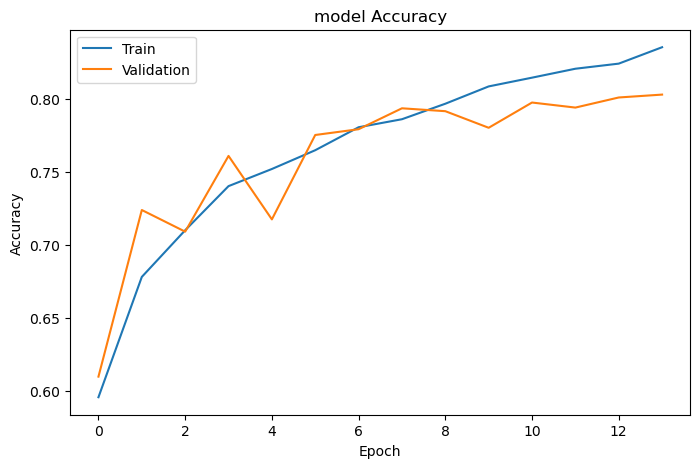

In [28]:
# step 7 : Accuracy Graph

plt.figure(figsize =(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.show()

## Accuracy Graph

* Training accuracy increased from 59.5% to 83.5% , showing the model learned important image features over time.
* Validation accuracy improved from 61.0% to 80.3 %, Indicating good performance on unseen images.
* Both training and validation accuracy curves rise steadily, which suggest effective learning.
* The gap between training accuracy (83.5%) and validation accuracy (80.3%) is small(~4%), indicating minimal overfitting.
* Validation accuracy becomes stable after around Epoch 14-15, meaning the model has largely converged.
* Data augmentation and dropout helped improve generalization and prevent overfitting.
* The final validation accuracy of 80% + shows the CNN model can reliably classify cats and dogs.

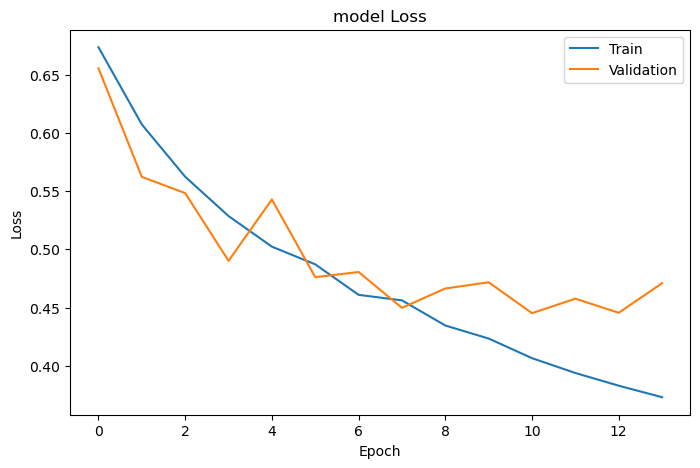

In [29]:
# step 8 : Loss Graph

plt.figure(figsize =(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])

plt.show()

## Loss Graph Insights
- Training loss decreased from 0.70 to 0.35, showing the model learned effectively during training.
- Validation loss decreased from 0.66 to 0.45, indicating improved performance on unseen data.
- Both curves show a downward trend, which means the model is successfully minimizing prediction errors.
- The validation loss remains slightly higher than the training loss, which is expected in real-world models.
- There is only a small gap between training and validation loss, indicating minimal overfitting.
- Around Epoch 14–16, validation loss becomes stable, suggesting the model has reached optimal learning.
- The final loss values indicate that the CNN model generalizes well to new cat and dog images.

In [31]:
# step 9 : Evaluate Model

loss,acc=model.evaluate(test_data)

print("Accuracy",acc)
print("Loss",loss)

64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 127ms/step - accuracy: 0.7978 - loss: 0.4452
Accuracy 0.797825038433075
Loss 0.4451707899570465


In [32]:
# step 10 : save model

model.save("cat_dog_cnn.h5")
print("Model saved Successfully!")

Model saved Successfully!


In [33]:
# step 11 : Load Model

model = load_model("cat_dog_cnn.h5")

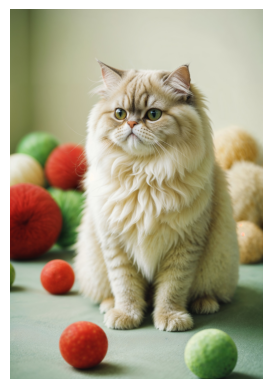

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
Prediction Score: 0.059374783


In [53]:
# step 12 : Predict New Image

img_path =r"C:\Users\LAPZONE\Downloads\cute-cat-lifestyle.jpg"

img = image.load_img(
    img_path
)

plt.imshow(img)
plt.axis("off")
plt.show()

img = image.load_img(img_path, target_size=(128,128))

img_arr = image.img_to_array(img)
img_arr = img_arr / 255.0
img_arr = np.expand_dims(img_arr, axis= 0)

pred = model.predict(img_arr)

print("Prediction Score:", pred[0][0])

In [54]:
# Step 13 : Final Prediction

if pred[0][0] < 0.5:
    print("Cat")
else:
    print("Dog")

Cat


In [37]:
pip install pillow-avif-plugin

   ---------------------------------------- 0.0/7.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.4 MB ? eta -:--:--
   - -----------------------------

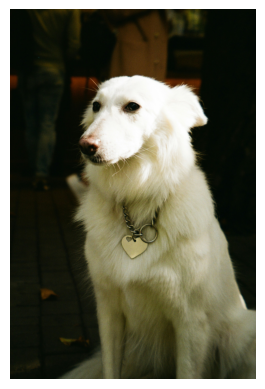

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
Prediction Score: 0.782251
Dog


In [56]:
import pillow_avif
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

model = load_model ("cat_dog_cnn.h5")
img_path = r"C:\Users\LAPZONE\Downloads\vlad-patana-pDTdcCS8MIk-unsplash.jpg"

img = image.load_img(img_path)

plt.imshow(img)
plt.axis("off")
plt.show()

img = image.load_img(img_path, target_size=(128,128))

img_arr = image.img_to_array(img)
img_arr = img_arr / 255.0
img_arr = np.expand_dims(img_arr,axis = 0)

pred = model.predict(img_arr)

print("Prediction Score:", pred[0][0])

if pred [0][0] > 0.5:
    print("Dog")
else:
    print("Cat")

## Conclusion

The Cat vs Dog Classification project successfully used a CNN model to classify images with an accuracy of 80.8%. The model effectively learned image features through convolution and pooling layers, demonstrating the potential of deep learning for image classification tasks.